# Additional benchmark with VIA

***

Jan T. Schleicher, 2025

We run [VIA](https://pyvia.readthedocs.io/en/latest/index.html) as an additional comparison to infer trajectories and pseudotime.

In [1]:
import os

import matplotlib as mpl
import numpy as np
import pandas as pd
import pyVIA.core as via
import scanpy as sc

/Users/janschleicher/miniconda3/envs/via/lib/python3.10/site-packages/phate/__init__.py


In [2]:
DATA_PATH = "../data/"
OUTPUT_PATH = "../output/"
FIGURES_PATH = "../figures/via/"
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

In [3]:
# Load preprocessed AnnData object
adata = sc.read_h5ad(os.path.join(DATA_PATH, "tex_data_chronic_annotated.h5ad"))
adata

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

In [4]:
# Initialize and run VIA
true_label = adata.obs["leiden"].tolist()
v0 = via.VIA(
    adata.obsm["X_pca"],
    true_label,
    knn=30,
    root_user=None,
    random_seed=42,
    velocity_matrix=adata.layers["velocity"],
    gene_matrix=adata.layers["log1p"].todense(),
    velo_weight=0.5,
)
v0.run_VIA()

2025-06-04 21:12:36.630511	Running VIA over input data of 13410 (samples) x 50 (features)
2025-06-04 21:12:36.630681	Knngraph has 30 neighbors
2025-06-04 21:12:39.457043	Finished global pruning of 30-knn graph used for clustering at level of 0.15. Kept 46.0 % of edges. 
2025-06-04 21:12:39.498343	Number of connected components used for clustergraph  is 1
2025-06-04 21:12:39.919073	Commencing community detection
2025-06-04 21:12:41.273030	Finished community detection. Found 317 clusters.
2025-06-04 21:12:41.275533	Merging 299 very small clusters (<10)
2025-06-04 21:12:41.279352	Finished detecting communities. Found 18 communities
2025-06-04 21:12:41.279856	Making cluster graph. Global cluster graph pruning level: 0.15
2025-06-04 21:12:41.302789	Graph has 1 connected components before pruning
2025-06-04 21:12:41.303931	Graph has 1 connected components after pruning
2025-06-04 21:12:41.303994	Graph has 1 connected components after reconnecting
2025-06-04 21:12:41.304212	0.0% links trimmed

  0%|          | 0/1300 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


memory for rw2 hittings times  2. Using rw2 based pt
2025-06-04 21:12:54.603525	Identifying terminal clusters corresponding to unique lineages...
2025-06-04 21:12:54.603548	Closeness:[0, 2, 3, 6, 7, 11, 12, 13, 17]
2025-06-04 21:12:54.603555	Betweenness:[0, 1, 2, 4, 5, 7, 11, 12, 13, 17]
2025-06-04 21:12:54.603560	Out Degree:[0, 1, 2, 5, 6, 7, 9, 11, 12, 13]
2025-06-04 21:12:54.603649	Cluster 2 had 3 or more neighboring terminal states [5, 6, 7] and so we removed cluster 5
2025-06-04 21:12:54.603669	Cluster 7 had 3 or more neighboring terminal states [0, 2, 6, 13] and so we removed cluster 6
2025-06-04 21:12:54.603676	We removed cluster 11 from the shortlist of terminal states
2025-06-04 21:12:54.603686	Cluster 13 had 3 or more neighboring terminal states [0, 1, 7] and so we removed cluster 1
2025-06-04 21:12:54.603737	Terminal clusters corresponding to unique lineages in this component are [0, 2, 7, 12, 13] 
2025-06-04 21:12:54.603750	Calculating lineage probability at memory 5


  0%|          | 0/1000 [00:00<?, ?it/s]

2025-06-04 21:12:56.510231	Cluster or terminal cell fate 0 is reached 837.0 times
2025-06-04 21:12:56.530144	Cluster or terminal cell fate 2 is reached 458.0 times
2025-06-04 21:12:56.545031	Cluster or terminal cell fate 7 is reached 842.0 times
2025-06-04 21:12:56.560357	Cluster or terminal cell fate 12 is reached 343.0 times
2025-06-04 21:12:56.575841	Cluster or terminal cell fate 13 is reached 866.0 times
2025-06-04 21:12:56.584926	There are (5) terminal clusters corresponding to unique lineages {0: '0', 2: '4', 7: '7', 12: '8', 13: '11'}
2025-06-04 21:12:56.584948	Begin projection of pseudotime and lineage likelihood
2025-06-04 21:12:56.972645	Transition matrix with weight of 0.5 on RNA velocity
2025-06-04 21:12:56.972905	Cluster graph layout based on forward biasing
2025-06-04 21:12:56.974298	Starting make edgebundle viagraph...
2025-06-04 21:12:56.974323	Make via clustergraph edgebundle
2025-06-04 21:12:57.186230	Hammer dims: Nodes shape: (18, 2) Edges shape: (64, 3)
2025-06-04 2

2025-06-04 21:12:57.206436	Marker_lineages: [0, 2, 7, 12, 13]
2025-06-04 21:12:57.211326	The number of components in the original full graph is 1
2025-06-04 21:12:57.211357	For downstream visualization purposes we are also constructing a low knn-graph 
2025-06-04 21:12:57.846354	Check sc pb 1.0000000000000002 
f getting majority comp
2025-06-04 21:12:58.045677	Cluster path on clustergraph starting from Root Cluster 17 to Terminal Cluster 0: [17, 3, 10, 15, 4, 9, 6, 7, 0]
2025-06-04 21:12:58.045732	Cluster path on clustergraph starting from Root Cluster 17 to Terminal Cluster 2: [17, 3, 10, 15, 4, 9, 6, 7, 2]
2025-06-04 21:12:58.045740	Cluster path on clustergraph starting from Root Cluster 17 to Terminal Cluster 7: [17, 3, 10, 15, 4, 9, 6, 7]
2025-06-04 21:12:58.045747	Cluster path on clustergraph starting from Root Cluster 17 to Terminal Cluster 12: [17, 3, 10, 15, 4, 16, 14, 12]
2025-06-04 21:12:58.045753	Cluster path on clustergraph starting from Root Cluster 17 to Terminal Cluster 

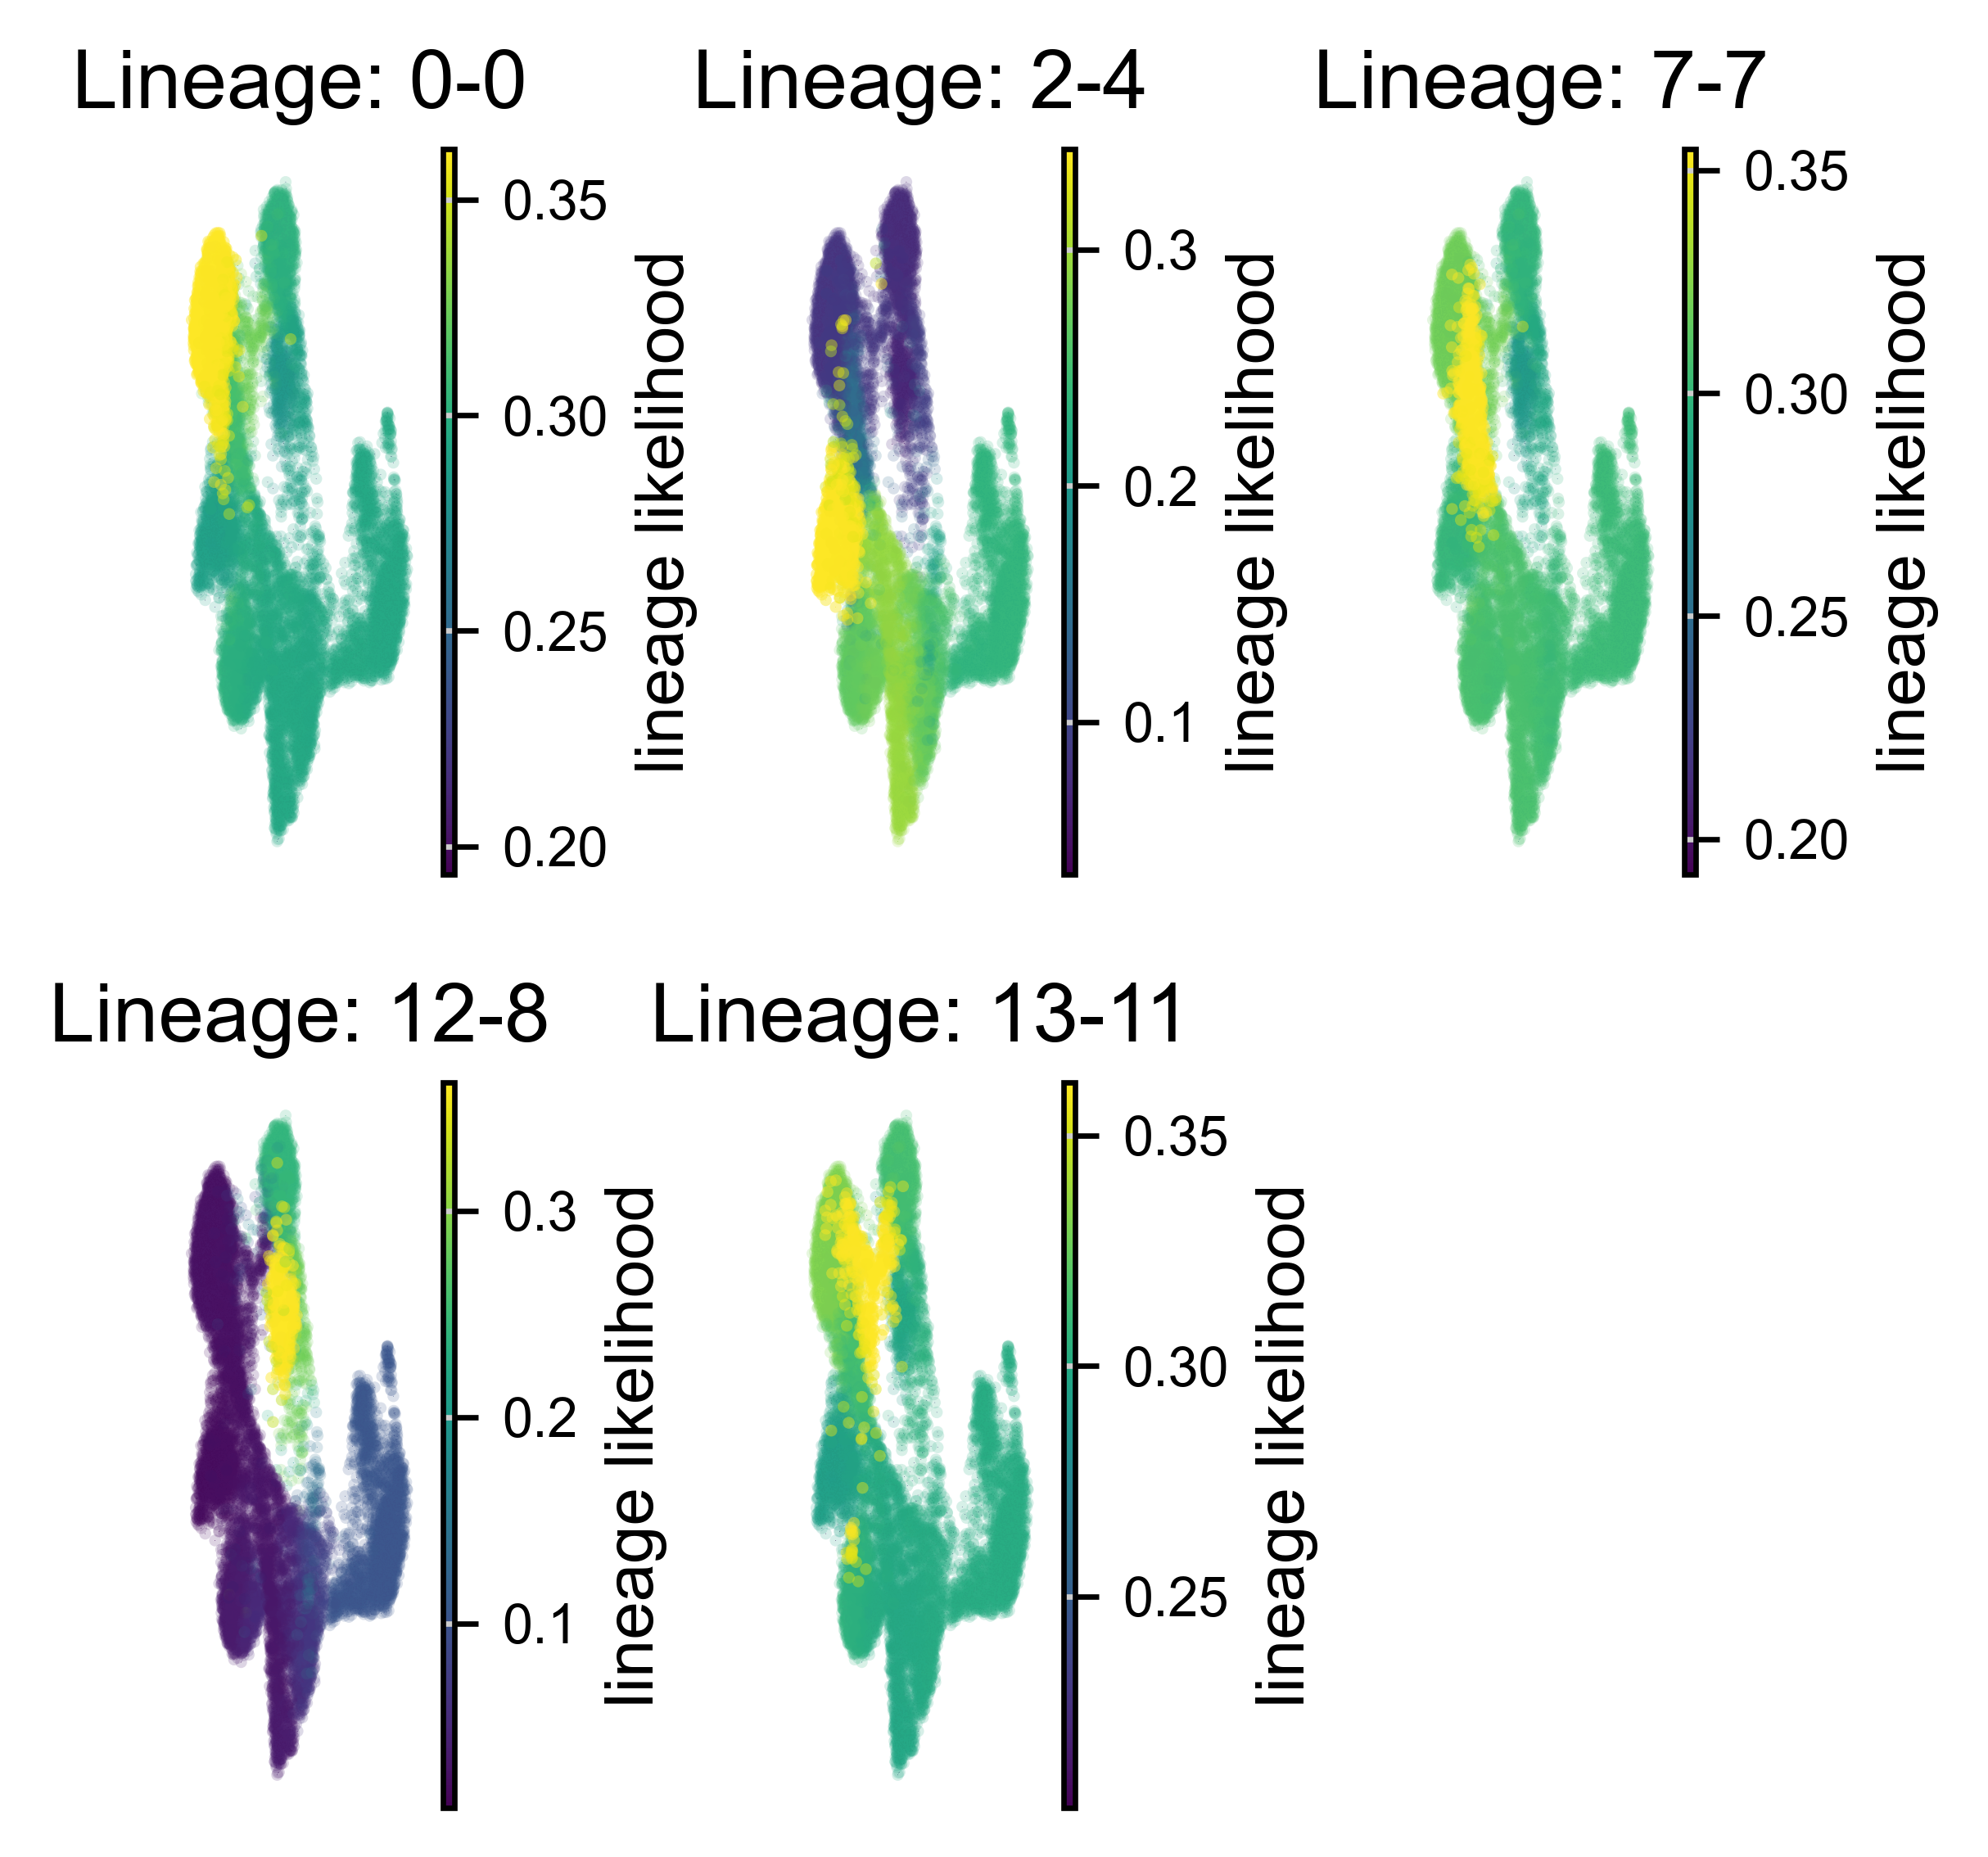

In [5]:
# Draw lineage likelihoods
fig, axs = via.plot_sc_lineage_probability(
    v0, embedding=adata.obsm["X_umap"], dpi=300, cmap_name="viridis", fontsize=10
)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "lineage_probabilities.pdf"))

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########               

2025-06-04 21:33:17.491763	Super cluster 0 is a super terminal with sub_terminal cluster 0
2025-06-04 21:33:17.492062	Super cluster 2 is a super terminal with sub_terminal cluster 2
2025-06-04 21:33:17.492100	Super cluster 7 is a super terminal with sub_terminal cluster 7
2025-06-04 21:33:17.492124	Super cluster 12 is a super terminal with sub_terminal cluster 12
2025-06-04 21:33:17.492142	Super cluster 13 is a super terminal with sub_terminal cluster 13


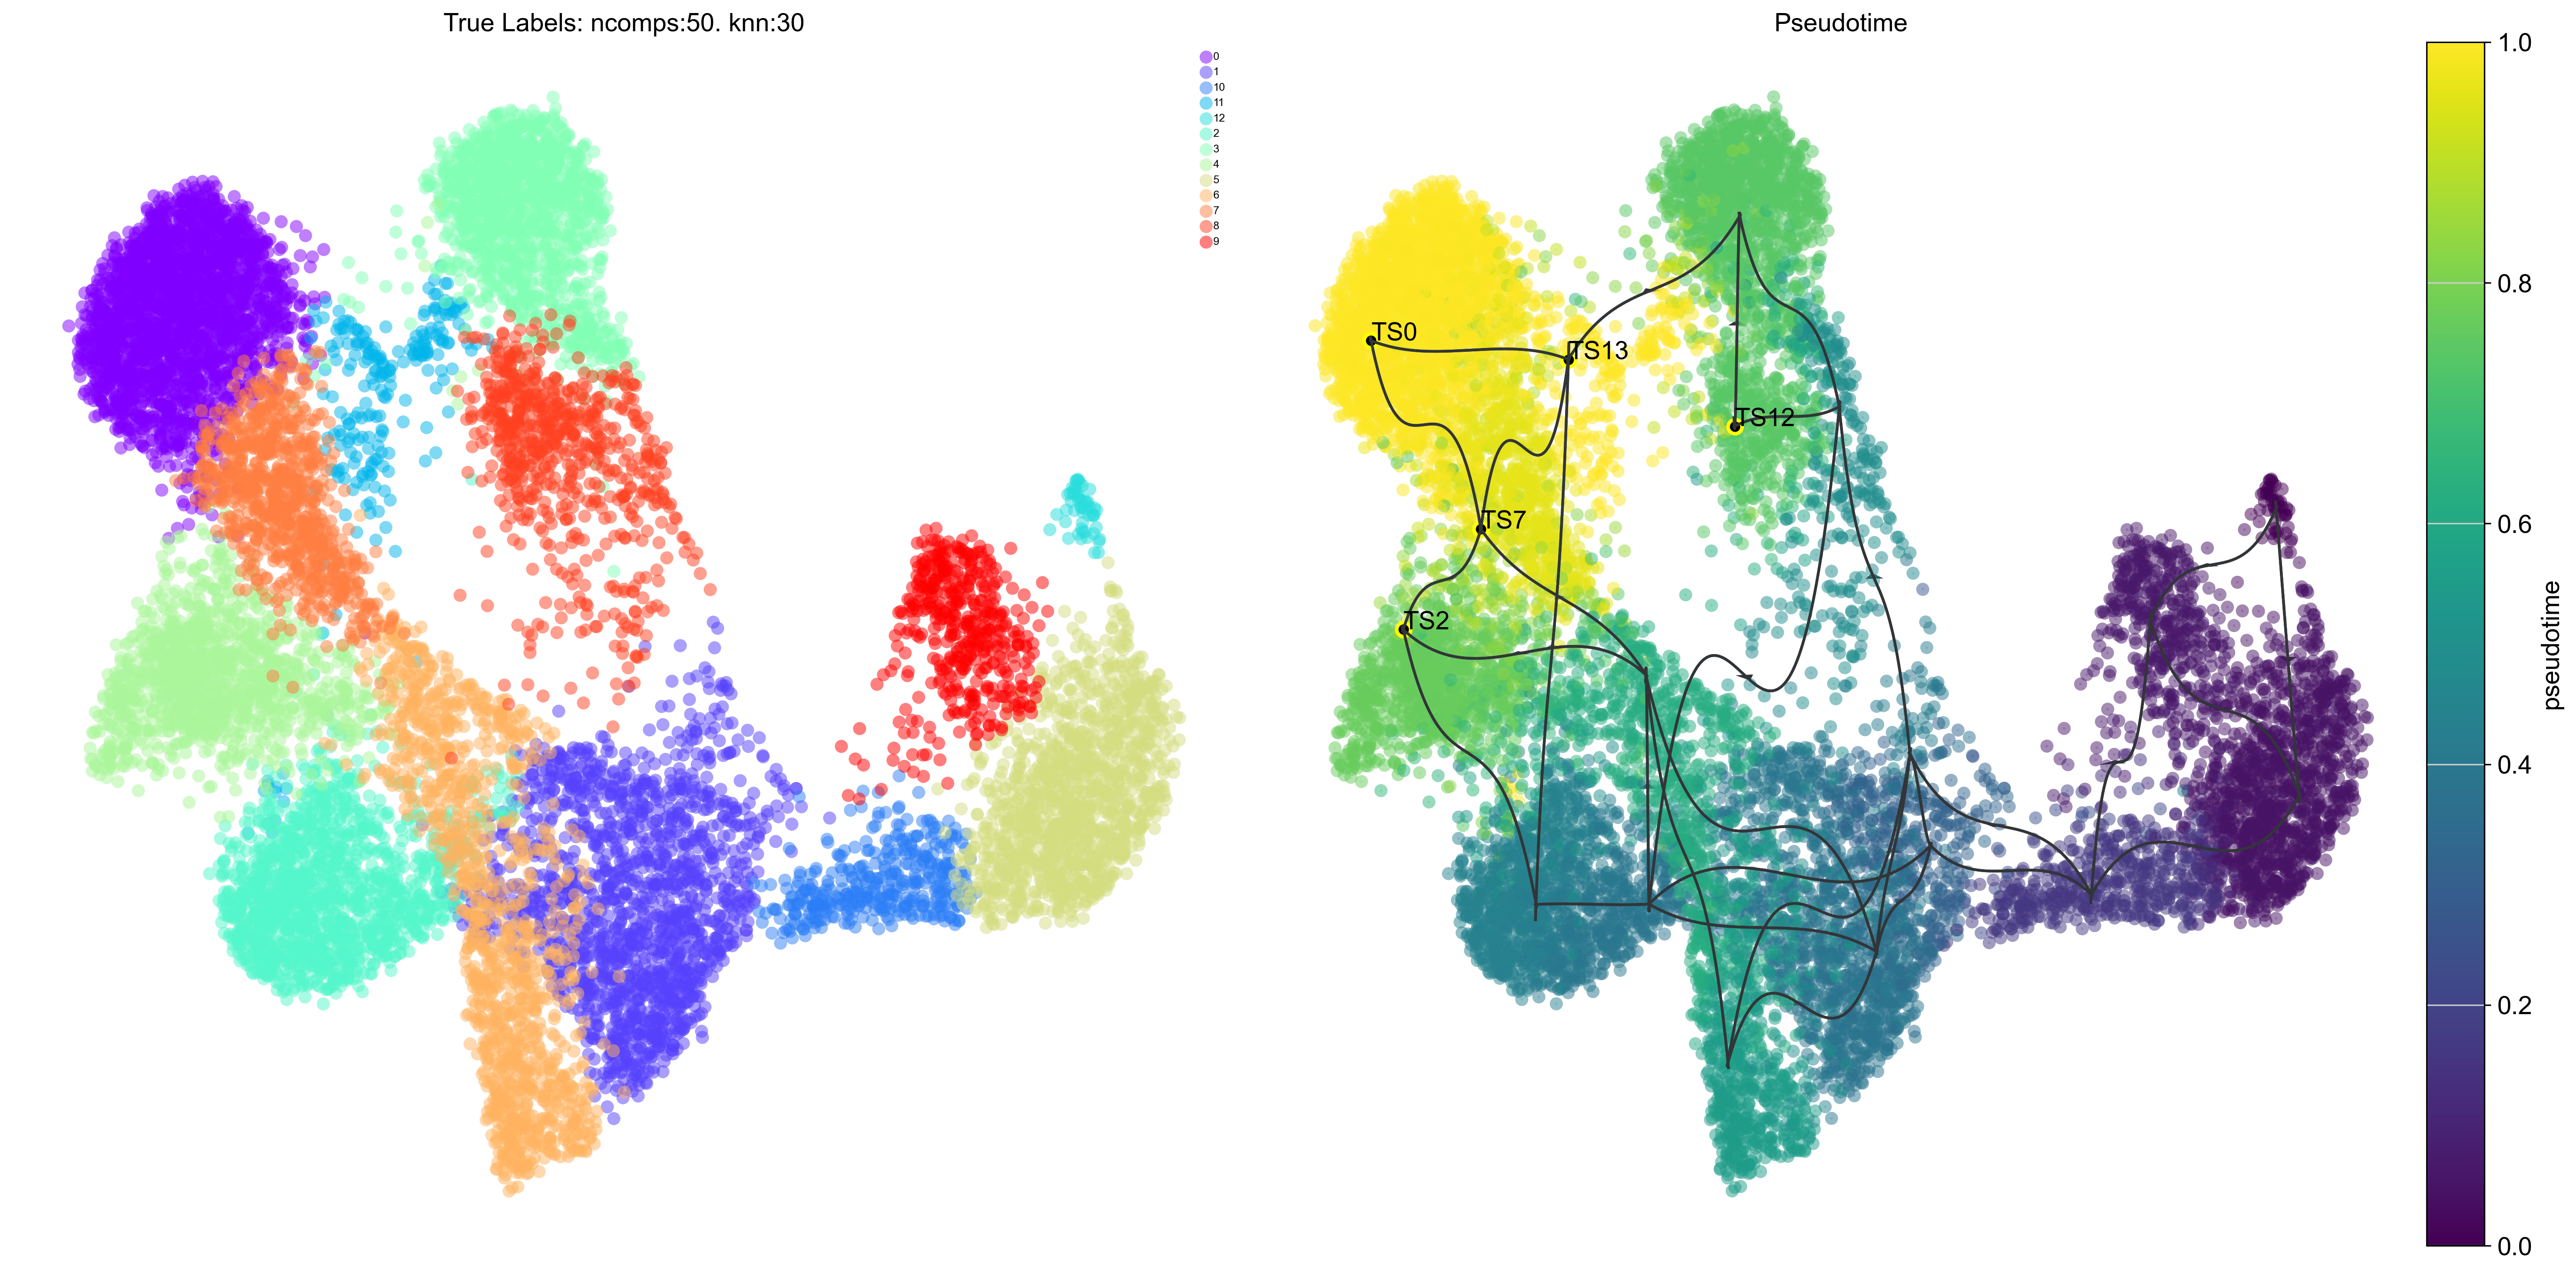

In [17]:
fig, ax1, ax2 = via.plot_trajectory_curves(
    v0, embedding=adata.obsm["X_umap"], cmap_pseudotime="viridis"
)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "trajectory_curves.pdf"))

via_curves = []
x_max = np.max(adata.obsm["X_umap"], axis=0)
for curve in ax2.get_lines():
    via_curves.append(curve.get_xydata() * x_max)
np.save(os.path.join(OUTPUT_PATH, "via_curves.npy"), via_curves)

annotations = [
    child for child in ax2.get_children() if isinstance(child, mpl.text.Annotation)
]
annotations_ = []
for annotation in annotations:
    if annotation.get_text().strip():
        x, y = annotation.xy * x_max
        annotations_.append({"x": x, "y": y, "text": annotation.get_text()})
annotations_df = pd.DataFrame(annotations_)
annotations_df.to_csv(os.path.join(OUTPUT_PATH, "via_terminal_states.csv"))

In [7]:
via_pseudotime = pd.Series(v0.single_cell_pt_markov, index=adata.obs_names)
via_pseudotime.to_csv(os.path.join(OUTPUT_PATH, "via_pst.csv"))